# Notebook 2: Building Neural Networks with PyTorch

Ghana AI Talent Accelerator - Deep Learning Foundations

Speedykom Group GmbH

## Learning Objectives

At the end of this notebook, you will be able to:

- **Build neural networks using PyTorch** with `torch.nn.Module`
- **Define layers** (Linear, Conv2D, RNN, Dropout, etc.)
- **Create training loops** with forward pass, loss calculation,
  backward pass, optimization
- **Use GPU** for training (device specification in PyTorch)
- **Monitor training** with loss plots and validation metrics
- **Save and load models** for inference and deployment
- **Understand convolutional layers** for image processing
- **Apply techniques to prevent overfitting**: Dropout, L2
  regularization
- **Debug PyTorch code** and understand common errors
- **Transfer learning**: Use pre-trained models and fine-tune them

------------------------------------------------------------------------

<a href="https://colab.research.google.com/github/Speedykom/GIZ_GhanaAI_Training_Materials/blob/main/06-deep-learning/intro_DL2.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **IMPORTANT: Enable GPU Before Running!**
>
> **Before you run any code, you MUST enable GPU acceleration:**
>
> 1.  Click **Runtime** in the top menu
> 2.  Select **Change runtime type**
> 3.  Under **Hardware accelerator**, select **T4 GPU**
> 4.  Click **Save**
>
> Without GPU, training will be extremely slow (or may not work
> properly).

# Setup Instructions

## Before You Start

This notebook uses the **real German Traffic Sign Recognition Benchmark
(GTSRB)** dataset with actual photographs.

### Option 1: Run Setup Script (Recommended for Local)

If running locally, first download the dataset:

``` bash
# Run the setup script to download and organize the data
python setup_gtsrb.py
```

This will:

- Download ~300MB of real traffic sign images
- Organize them into train/val/test folders
- Takes about 2-3 minutes

### Option 2: Google Colab (Easiest)

Click the **“Open in Colab”** badge above. The notebook will
automatically download data when you run the first code cell.

### Required Dependencies

If running locally, ensure you have:

``` bash
pip install torch torchvision matplotlib seaborn scikit-learn pillow
```

------------------------------------------------------------------------

# From Tabular Data to Images

## Recap: What We Learned in Notebook 1

In the previous notebook, we built a neural network to predict rain
using **tabular data**:

- 4 numerical features (Rainfall, Humidity, Pressure, RainToday)
- Fully connected layers
- Binary classification (Rain/No Rain)

This worked well because:

- The features were simple numbers
- Each feature was independent
- No spatial relationships to consider

## The Image Challenge

Now imagine trying to recognize traffic signs using the same approach:

- **Image size**: 64×64 pixels = 4,096 values per image
- **With 3 color channels**: 64 × 64 × 3 = 12,288 values
- **Classes**: Stop signs, yield signs, speed limits, etc.

If we tried to use fully connected layers:

$$\text{Input} = 12,288 \text{ pixels}$$
$$\text{First hidden layer (100 neurons)} = 12,288 \times 100 = 1,228,800 \text{ parameters}$$

That’s **1.2 million parameters** just for the first layer!

**Problems:**

1.  **Memory**: Too many parameters to store
2.  **Overfitting**: Too many parameters relative to training data
3.  **Computation**: Expensive matrix multiplications
4.  **Ignores structure**: No concept of “nearby pixels”

**We need Convolutional Neural Networks (CNNs).**

> **Mental Model: The Detective with a Flashlight (How CNNs “See”)**
>
> Imagine looking at a 1080p image (2 million pixels) all at once.
> Overwhelming, right?
>
> A **Convolution** is like a detective in a dark room with a **small
> square flashlight**:
>
> 1.  **The Flashlight (Kernel/Filter):** The detective only shines
>     light on a small 3×3 patch at a time.
>
> 2.  **Scanning Top-to-Bottom:** They methodically move the flashlight
>     across the entire image, one small patch at a time.
>
> 3.  **Different Flashlights for Different Clues:**
>
>     - One flashlight (filter) detects **vertical edges** (door frames,
>       tree trunks)
>     - Another detects **horizontal edges** (roads, horizons)
>     - Another detects **curves** (eyes, wheels)
>     - Another detects **textures** (fur, leaves)
>
> 4.  **Building Up Understanding:** Layer after layer, the detective
>     builds from simple clues (edges) to complex objects (this is a
>     cat, this is a stop sign).
>
> This is why CNNs are so efficient—they don’t look at the whole image
> at once. They scan systematically with specialized “flashlights”!

------------------------------------------------------------------------

# CPUs vs GPUs: Why Hardware Matters for Deep Learning

## What Are CPUs and GPUs?

Before we dive into CNNs, let’s understand the hardware that makes deep
learning possible.

### CPU (Central Processing Unit)

The **CPU** is the “brain” of your computer—the chip that runs your
operating system, browsers, and applications.

**Key characteristics:**

- **Few powerful cores**: 4-16 cores on most laptops
- **High clock speed**: 2-5 GHz (very fast individual operations)
- **General purpose**: Designed for sequential tasks (running programs,
  opening files, etc.)
- **Optimized for**: Complex logic, decision-making, running operating
  systems

**Analogy**: A CPU is like a Formula 1 race car—extremely fast and
agile, but expensive and limited capacity.

### GPU (Graphics Processing Unit)

The **GPU** was originally designed for rendering graphics (video games,
3D modeling), but it turns out to be perfect for deep learning!

**Key characteristics:**

- **Thousands of simple cores**: 1,000-10,000+ cores on modern GPUs
- **Lower clock speed**: 1-2 GHz per core (slower individually)
- **Specialized for parallel tasks**: Designed to do the same operation
  on many data points simultaneously
- **Optimized for**: Matrix operations, image processing, deep learning

**Analogy**: A GPU is like a fleet of 1,000 delivery trucks—not as fast
individually, but can deliver 1,000 packages at once instead of one by
one.

## Why GPUs Are Better for Deep Learning

### The Parallel Processing Advantage

Training a neural network involves **millions of matrix
multiplications**. Here’s why GPUs excel:

**CPU approach (sequential):**

    Calculate layer 1 → Calculate layer 2 → Calculate layer 3 → ... → Update weights
    (One operation at a time)

**GPU approach (parallel):**

    Calculate ALL neurons in layer 1 SIMULTANEOUSLY
    ↓
    Calculate ALL neurons in layer 2 SIMULTANEOUSLY
    ↓
    Update ALL weights SIMULTANEOUSLY

**Example:** Processing a 64×64 image with 32 filters:

- **CPU**: Processes each pixel one at a time → Takes minutes
- **GPU**: Processes all 4,096 pixels simultaneously → Takes seconds

### Real-World Speed Comparison

| Task                        | CPU Time  | GPU Time   | Speedup         |
|-----------------------------|-----------|------------|-----------------|
| Training MNIST (1 epoch)    | 5 minutes | 10 seconds | **30x faster**  |
| Training ResNet on ImageNet | 2 weeks   | 3 days     | **4-5x faster** |
| Processing 10,000 images    | 1 hour    | 2 minutes  | **30x faster**  |

## Why Gaming Laptops Have GPUs

**Video games require the same operations as deep learning!**

Both need to:

- Process millions of pixels simultaneously
- Apply transformations to 3D objects
- Render frames at 60+ frames per second
- Perform matrix operations for physics and lighting

That’s why **gaming laptops** (with NVIDIA GTX/RTX cards) are popular
for deep learning—they already have powerful GPUs!

### GPU Specs That Matter

**Key specs to look for:**

1.  **VRAM (Video RAM)**: 4GB minimum, 8GB+ recommended

2.  - Stores model parameters and batch data
    - Larger models need more VRAM

3.  **CUDA Cores**: More cores = more parallel processing

    - NVIDIA GTX 1650: 896 cores
    - NVIDIA RTX 4090: 16,384 cores

4.  **Memory Bandwidth**: How fast data moves to/from GPU

5.  - Higher bandwidth = faster training

## What If You Don’t Have a GPU?

### Option 1: Use Google Colab (Recommended for Beginners)

**Google Colab** provides **FREE** GPU access!

**How to enable GPU in Colab:**

1.  Open your notebook in Colab
2.  Go to **Runtime** → **Change runtime type**
3.  Select **GPU** from the hardware accelerator dropdown
4.  Click **Save**

**Colab GPU specs:**

- **Free tier**: NVIDIA Tesla T4 (16GB VRAM)
- **Pro tier**: NVIDIA Tesla V100 or A100 (faster)

**Limitations:**

- Sessions timeout after ~12 hours of inactivity
- Free tier has daily usage limits
- Files don’t persist between sessions (unless you save to Google Drive)

**Why we use Colab badges in our notebooks:**

``` markdown
<a href="https://colab.research.google.com/...">
  <img src="https://colab.research.google.com/assets/colab-badge.svg"/>
</a>
```

This lets you run the notebook immediately with GPU access!

### Option 2: Use CPU (Slower but Works)

**When CPU is fine:**

- Learning and prototyping (small models)
- Running pre-trained models (inference only)
- Working with tiny datasets (\<1,000 images)
- Educational purposes (like this course!)

**When you NEED a GPU:**

- Training large CNNs from scratch
- Working with large datasets (\>10,000 images)
- Training for many epochs (\>50)
- Research or production models

### Option 3: Cloud GPU Services

If you outgrow Colab:

- **Google Cloud Platform (GCP)**: \$0.50-\$2.50/hour
- **Amazon Web Services (AWS)**: Similar pricing
- **Lambda Labs**: \$0.60-\$1.50/hour (cheaper option)
- **Paperspace**: \$0.40-\$1.20/hour

**Cost example:** Training a model for 10 hours on a V100 GPU ≈ \$15-25

## Checking Your GPU

Let’s check what hardware you have available:

In [1]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    print("✅ GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️  GPU not available. Using CPU.")
    print("Training will be slower, but still works for learning!")
    print("\n💡 Tip: Click the 'Open in Colab' badge above to use a free GPU")

# Set device for the rest of the notebook
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

✅ GPU is available!
GPU Name: NVIDIA RTX A2000 Laptop GPU
GPU Memory: 4.29 GB
CUDA Version: 12.8

Using device: cuda:0

## Summary

| Aspect | CPU | GPU | Recommendation |
|-----------------|-----------|-----------|---------------------------------|
| **Speed** | Slow for deep learning | 10-50x faster | Use GPU for training |
| **Cost** | Free (built-in) | \$500-\$2,000+ | Start with Colab (free) |
| **Best for** | Prototyping, inference | Training large models | GPU for serious work |
| **Learning** | Perfectly fine! | Nice to have | CPU is OK for this course |

**Bottom line:** Don’t worry if you don’t have a GPU! This course is
designed to work on CPU for learning purposes. When you’re ready for
larger projects, use Google Colab’s free GPU or invest in hardware
later.

------------------------------------------------------------------------

# Understanding Convolutions

## The Sliding Window Concept

A **convolution** slides a small matrix (called a **kernel** or
**filter**) across an image and computes dot products at each position.

**Key insights:**

- The same kernel is reused across the entire image (**weight sharing**)
- A 3×3 kernel has only 9 parameters, regardless of image size
- The kernel naturally operates on local neighborhoods

Let’s see this in action:

In [2]:
# Import PyTorch - our deep learning framework
import torch
import torch.nn as nn          # Neural network layers (Conv2d, Linear, etc.)
import torch.nn.functional as F # Activation functions (ReLU, softmax, etc.)
import torch.optim as optim     # Optimizers (Adam, SGD) - for updating weights
import torchvision              # Tools for computer vision (datasets, transforms)
import torchvision.transforms as transforms  # Image preprocessing
from torch.utils.data import DataLoader, Dataset  # For batching data

# Import other useful libraries
import matplotlib.pyplot as plt  # For plotting images and graphs
import seaborn as sns            # For better-looking plots (heatmaps, etc.)
import numpy as np               # For numerical operations
from pathlib import Path         # For file paths
import pandas as pd              # For data manipulation (though we'll use tensors)
from PIL import Image            # For loading images
from sklearn.metrics import confusion_matrix, classification_report  # For evaluation
import warnings
warnings.filterwarnings('ignore')

# Set device - GPU if available, otherwise CPU
# This will use the GPU we discussed in the section above
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
# This ensures we get the same results every time we run the code
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: cuda:0

### Manual Edge Detection

Input Image (Vertical Edge at Column 3):
[[0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1. 1. 1.]]

Vertical Edge Detector Kernel:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

How it works:
- Left column: -1 (dark)
- Middle column: 0 (neutral)
- Right column: +1 (bright)
- Result: High values at vertical edges

Convolution Output:
[[ 0.  0.  2.  2.  0.  0. -2.]
 [ 0.  0.  3.  3.  0.  0. -3.]
 [ 0.  0.  3.  3.  0.  0. -3.]
 [ 0.  0.  3.  3.  0.  0. -3.]
 [ 0.  0.  3.  3.  0.  0. -3.]
 [ 0.  0.  3.  3.  0.  0. -3.]
 [ 0.  0.  2.  2.  0.  0. -2.]]

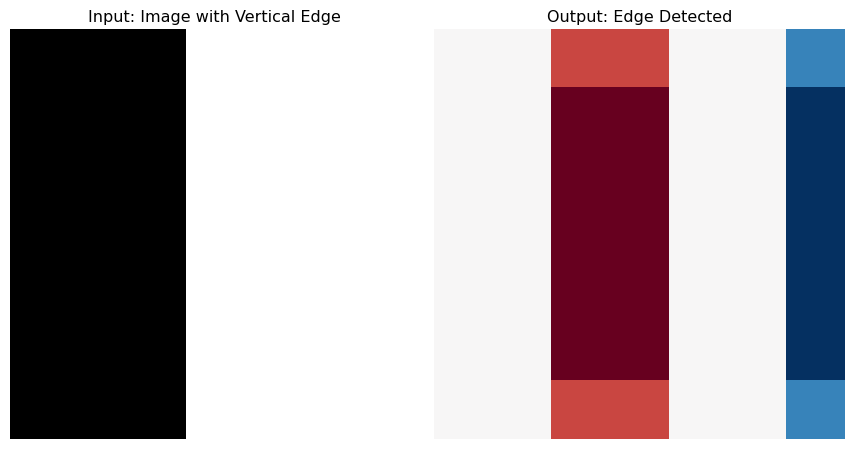

In [3]:
# Create a simple 7x7 image with a vertical edge
image = torch.zeros(1, 1, 7, 7)
image[0, 0, :, 3:] = 1.0  # Right half is white

print("Input Image (Vertical Edge at Column 3):")
print(image[0, 0].numpy())

# Define a vertical edge detector kernel
# This kernel detects vertical edges by looking for differences 
# between left and right sides
vertical_kernel = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32).view(1, 1, 3, 3)

print("\nVertical Edge Detector Kernel:")
print(vertical_kernel[0, 0].numpy())
print("\nHow it works:")
print("- Left column: -1 (dark)")
print("- Middle column: 0 (neutral)")  
print("- Right column: +1 (bright)")
print("- Result: High values at vertical edges")

# Apply convolution
output = F.conv2d(image, vertical_kernel, padding=1)

print("\nConvolution Output:")
print(output[0, 0].numpy())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(image[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Input: Image with Vertical Edge')
axes[0].axis('off')

axes[1].imshow(output[0, 0].numpy(), cmap='RdBu_r')
axes[1].set_title('Output: Edge Detected')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**What happened?**

- The kernel detected where black meets white
- High positive values on the left side of the edge
- High negative values on the right side
- Near zero in uniform regions

### Different Kernels Detect Different Features

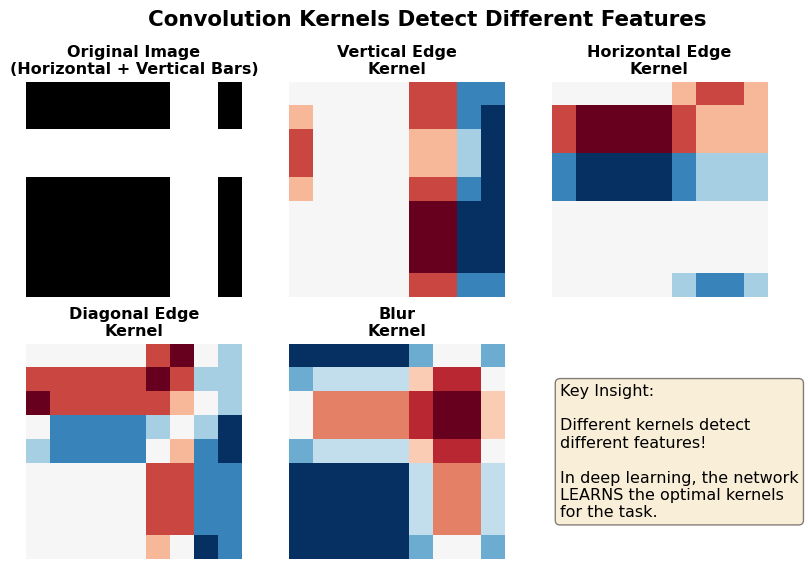

In [4]:
kernels = {
    'Vertical Edge': torch.tensor([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=torch.float32),
    'Horizontal Edge': torch.tensor([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=torch.float32),
    'Diagonal Edge': torch.tensor([[-1, -1, 0], [-1, 0, 1], [0, 1, 1]], dtype=torch.float32),
    'Blur': torch.tensor([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=torch.float32) / 9,
}

# Create test image with both horizontal and vertical features
test_image = torch.zeros(1, 1, 9, 9)
test_image[0, 0, 2:4, :] = 1.0  # Horizontal bar
test_image[0, 0, :, 6:8] = 1.0  # Vertical bar

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

axes[0].imshow(test_image[0, 0].numpy(), cmap='gray')
axes[0].set_title('Original Image\n(Horizontal + Vertical Bars)', fontweight='bold')
axes[0].axis('off')

for idx, (name, kernel) in enumerate(kernels.items(), 1):
    kernel_tensor = kernel.view(1, 1, 3, 3)
    output = F.conv2d(test_image, kernel_tensor, padding=1)
    
    axes[idx].imshow(output[0, 0].numpy(), cmap='RdBu_r')
    axes[idx].set_title(f'{name}\nKernel', fontweight='bold')
    axes[idx].axis('off')

# Add explanation
axes[5].axis('off')
axes[5].text(0.1, 0.5, 
    "Key Insight:\n\n"
    "Different kernels detect\n"
    "different features!\n\n"
    "In deep learning, the network\n"
    "LEARNS the optimal kernels\n"
    "for the task.",
    fontsize=12, verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Convolution Kernels Detect Different Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

------------------------------------------------------------------------

# From Grayscale to RGB: Understanding Image Channels

Before we tackle the German road signs, let’s bridge what we learned in
Notebook 1 with what we need for color images.

## Recap: MNIST is Grayscale (1 Channel)

In Notebook 1, we worked with MNIST:

- **Shape**: `(batch_size, 1, 28, 28)`
- **1 channel**: Grayscale intensity (0-255)
- **Tensor structure**: `[batch, channels, height, width]`

In [5]:
# Load MNIST to remind ourselves
from torchvision import datasets
import torch

mnist = datasets.MNIST('./data', train=True, download=True)
image, label = mnist[0]

print(f"MNIST image shape: {torch.tensor(np.array(image)).shape}")
print(f"When we add batch dimension: {torch.tensor(np.array(image)).unsqueeze(0).unsqueeze(0).shape}")
print(f"PyTorch format (N, C, H, W): (1, 1, 28, 28)")

MNIST image shape: torch.Size([28, 28])
When we add batch dimension: torch.Size([1, 1, 28, 28])
PyTorch format (N, C, H, W): (1, 1, 28, 28)

## Color Images: RGB (3 Channels)

Real-world images use **RGB** (Red, Green, Blue):

- **Shape**: `(batch_size, 3, height, width)`
- **3 channels**: One for each color
- **Why 3?** Human eyes have receptors for Red, Green, and Blue

### How RGB Works

Each pixel has 3 values instead of 1:

- **Red channel**: How much red (0-255)
- **Green channel**: How much green (0-255)  
- **Blue channel**: How much blue (0-255)

**White pixel**: (255, 255, 255) - all colors at max **Black pixel**:
(0, 0, 0) - no color **Red pixel**: (255, 0, 0) - only red **Yellow
pixel**: (255, 255, 0) - red + green

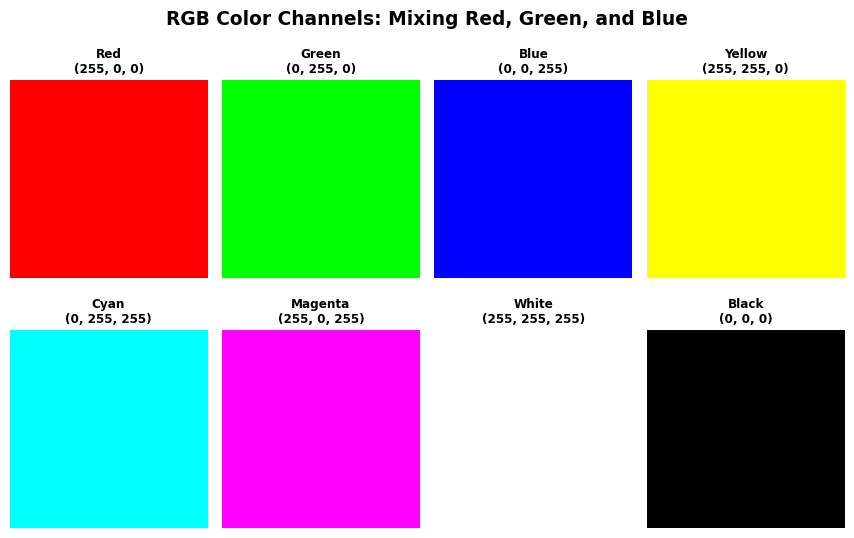

In [6]:
# Create a simple RGB demonstration
fig, axes = plt.subplots(2, 4, figsize=(9, 6))

# Pure colors
red = torch.zeros(3, 50, 50)
red[0] = 1.0  # Red channel

green = torch.zeros(3, 50, 50)
green[1] = 1.0  # Green channel

blue = torch.zeros(3, 50, 50)
blue[2] = 1.0  # Blue channel

# Mixtures
yellow = torch.zeros(3, 50, 50)
yellow[0] = 1.0  # Red
yellow[1] = 1.0  # Green

cyan = torch.zeros(3, 50, 50)
cyan[1] = 1.0  # Green
cyan[2] = 1.0  # Blue

magenta = torch.zeros(3, 50, 50)
magenta[0] = 1.0  # Red
magenta[2] = 1.0  # Blue

white = torch.ones(3, 50, 50)

black = torch.zeros(3, 50, 50)

colors = [
    (red, 'Red\n(255, 0, 0)'),
    (green, 'Green\n(0, 255, 0)'),
    (blue, 'Blue\n(0, 0, 255)'),
    (yellow, 'Yellow\n(255, 255, 0)'),
    (cyan, 'Cyan\n(0, 255, 255)'),
    (magenta, 'Magenta\n(255, 0, 255)'),
    (white, 'White\n(255, 255, 255)'),
    (black, 'Black\n(0, 0, 0)')
]

for ax, (color_tensor, title) in zip(axes.flat, colors):
    ax.imshow(color_tensor.permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('RGB Color Channels: Mixing Red, Green, and Blue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualizing Individual Channels

Let’s decompose a color image into its RGB channels:

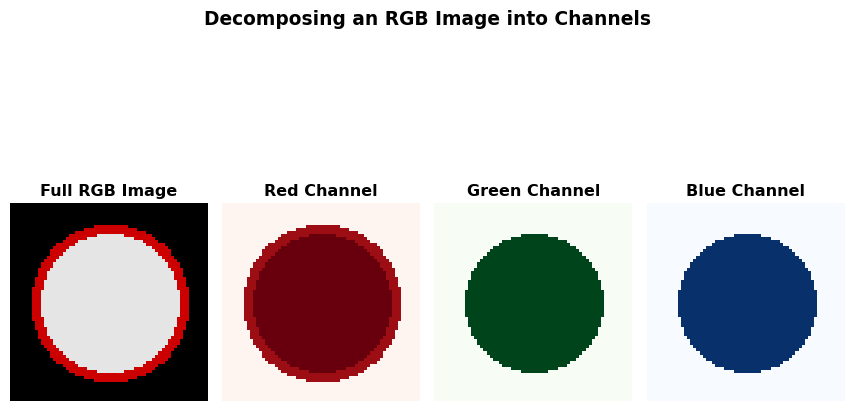

Image shape: torch.Size([3, 64, 64])
  - Channel 0 (Red): torch.Size([64, 64])
  - Channel 1 (Green): torch.Size([64, 64])
  - Channel 2 (Blue): torch.Size([64, 64])

In [7]:
# Create a simple traffic sign-like image
img_size = 64
sign_image = torch.zeros(3, img_size, img_size)

# Create a red circle (stop sign-like)
center = img_size // 2
for i in range(img_size):
    for j in range(img_size):
        dist = np.sqrt((i - center)**2 + (j - center)**2)
        if dist < img_size * 0.4:
            sign_image[0, i, j] = 0.8  # Red
        if dist < img_size * 0.35:
            sign_image[0, i, j] = 0.9
            sign_image[1, i, j] = 0.9
            sign_image[2, i, j] = 0.9

# Visualize the full image and each channel
fig, axes = plt.subplots(1, 4, figsize=(9, 6))

# Full RGB image
axes[0].imshow(sign_image.permute(1, 2, 0).numpy())
axes[0].set_title('Full RGB Image', fontweight='bold')
axes[0].axis('off')

# Individual channels
axes[1].imshow(sign_image[0].numpy(), cmap='Reds')
axes[1].set_title('Red Channel', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(sign_image[1].numpy(), cmap='Greens')
axes[2].set_title('Green Channel', fontweight='bold')
axes[2].axis('off')

axes[3].imshow(sign_image[2].numpy(), cmap='Blues')
axes[3].set_title('Blue Channel', fontweight='bold')
axes[3].axis('off')

plt.suptitle('Decomposing an RGB Image into Channels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Image shape: {sign_image.shape}")
print(f"  - Channel 0 (Red): {sign_image[0].shape}")
print(f"  - Channel 1 (Green): {sign_image[1].shape}")
print(f"  - Channel 2 (Blue): {sign_image[2].shape}")

## Convolutions on Multi-Channel Images

Here’s where it gets interesting. When we apply a convolution to an RGB
image:

1.  **Input**: 3 channels (R, G, B)
2.  **Kernel**: 3×3×3 (height × width × input_channels)
3.  **Output**: 1 channel (feature map)

**The kernel has depth!** Each of the 3 input channels gets its own 3×3
filter, and the results are summed.

In [8]:
# Demonstrate multi-channel convolution
print("Multi-Channel Convolution:")
print("=" * 50)
print(f"Input shape: (batch, 3, 64, 64)")
print(f"Kernel shape: (out_channels, in_channels, 3, 3)")
print(f"  - For 1 output channel: (1, 3, 3, 3)")
print(f"  - That's 3 filters (one per input channel), each 3×3")
print(f"  - Total parameters: 3 × 3 × 3 = 27 weights + 1 bias = 28")

# Create example
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)
print(f"\nActual Conv2d parameters: {sum(p.numel() for p in conv.parameters())}")
print(f"  Weight shape: {conv.weight.shape}")
print(f"  Bias shape: {conv.bias.shape}")

Multi-Channel Convolution:
Input shape: (batch, 3, 64, 64)
Kernel shape: (out_channels, in_channels, 3, 3)
  - For 1 output channel: (1, 3, 3, 3)
  - That's 3 filters (one per input channel), each 3×3
  - Total parameters: 3 × 3 × 3 = 27 weights + 1 bias = 28

Actual Conv2d parameters: 28
  Weight shape: torch.Size([1, 3, 3, 3])
  Bias shape: torch.Size([1])

### Why This Matters for German Road Signs

German traffic signs are color-coded:

- **Red**: Stop, No Entry (prohibitory)
- **Blue**: Mandatory direction
- **Yellow/White**: Warning, Priority

The CNN will learn to use color information from all 3 channels to
distinguish sign types!

------------------------------------------------------------------------

# Project: German Traffic Sign Recognition

## The Problem

We’ll build a system to recognize German traffic signs. This is a
real-world computer vision task used in self-driving cars.

**Dataset**: German Traffic Sign Recognition Benchmark (GTSRB)

- 43 different traffic sign classes
- Over 50,000 images
- Various lighting conditions, angles, and weather

**Our simplified version**: We’ll focus on 4 common signs first:

1.  **Priority Road** (priority_road)
2.  **Give Way** (give_way)  
3.  **Stop** (stop)
4.  **No Entry** (no_entry)

## Loading and Exploring the Data

### Downloading the Real GTSRB Dataset

We’ll use the actual **German Traffic Sign Recognition Benchmark
(GTSRB)** dataset with real photographs of traffic signs taken in
various conditions.

**Dataset Source**: [German Traffic Sign Recognition
Benchmark](https://benchmark.ini.rub.de/?section=gtsrb&subsection=dataset)

The dataset contains:

- **43 different traffic sign classes**
- **Over 50,000 images** with varying lighting, angles, and weather
  conditions
- **Real-world photographs** (not synthetic)

We’ll focus on 4 important signs:

- **Priority Road** (yellow diamond) - Class 12
- **Give Way** (inverted triangle) - Class 13  
- **Stop** (octagon) - Class 14
- **No Entry** (red circle) - Class 17

In [9]:
# Download and prepare the dataset
# This downloads ~300MB of real traffic sign images

import urllib.request
import zipfile
from pathlib import Path
import shutil

# Download if not already present
zip_path = "GTSRB_Final_Training_Images.zip"
if not Path(zip_path).exists() and not Path('GTSRB').exists():
    print("📥 Downloading GTSRB dataset (~300MB)...")
    url = "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("✅ Download complete!")

# Extract if not already extracted
if not Path('GTSRB').exists() and Path(zip_path).exists():
    print("📦 Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✅ Extraction complete!")
    # Remove zip to save space
    Path(zip_path).unlink()

# Class mapping from GTSRB documentation
CLASS_MAPPING = {
    12: 'priority_road',  # Yellow diamond
    13: 'give_way',       # Inverted triangle
    14: 'stop',           # Octagon
    17: 'no_entry'        # Red circle
}

print(f"\n📋 Selected classes:")
for class_id, class_name in CLASS_MAPPING.items():
    print(f"   Class {class_id:2d}: {class_name}")


📋 Selected classes:
   Class 12: priority_road
   Class 13: give_way
   Class 14: stop
   Class 17: no_entry

### Organizing the Data

Now we’ll organize the images into train/validation/test splits:

In [10]:
from glob import glob
import numpy as np

# Create directory structure
DATA_DIR = Path('data')
DATASETS = ['train', 'val', 'test']

for ds in DATASETS:
    for cls in CLASS_MAPPING.values():
        (DATA_DIR / ds / cls).mkdir(parents=True, exist_ok=True)

# Get all training folders
train_folders = sorted(glob('GTSRB/Final_Training/Images/*'))

print("📁 Organizing images into train/val/test splits...")
for class_id, class_name in CLASS_MAPPING.items():
    # Find the folder for this class (folders are named with leading zeros)
    class_folder = None
    for folder in train_folders:
        if folder.endswith(f'{class_id:05d}'):
            class_folder = folder
            break
    
    if class_folder:
        # Get all .ppm images for this class
        image_paths = np.array(glob(f'{class_folder}/*.ppm'))
        print(f"   {class_name:15s}: {len(image_paths)} images")
        
        # Shuffle for random split
        np.random.seed(42)
        np.random.shuffle(image_paths)
        
        # Split: 80% train, 10% val, 10% test
        n_train = int(0.8 * len(image_paths))
        n_val = int(0.9 * len(image_paths))
        
        splits = {
            'train': image_paths[:n_train],
            'val': image_paths[n_train:n_val],
            'test': image_paths[n_val:]
        }
        
        # Copy to organized directories
        for split_name, images in splits.items():
            for img_path in images:
                shutil.copy(img_path, DATA_DIR / split_name / class_name / Path(img_path).name)

print("\n✅ Dataset organization complete!")

📁 Organizing images into train/val/test splits...
   priority_road  : 2100 images
   give_way       : 2160 images
   stop           : 780 images
   no_entry       : 1110 images

✅ Dataset organization complete!

### Loading the Dataset with PyTorch

Now we use PyTorch’s `ImageFolder` to easily load the organized images:

In [11]:
from torchvision.datasets import ImageFolder

# Load datasets from organized directories
train_dataset = ImageFolder(DATA_DIR / 'train')
val_dataset = ImageFolder(DATA_DIR / 'val')
test_dataset = ImageFolder(DATA_DIR / 'test')

# Get class names
class_names = train_dataset.classes
print(f"Classes: {class_names}")
print(f"\n📊 Dataset sizes:")
print(f"   Training:   {len(train_dataset)} images")
print(f"   Validation: {len(val_dataset)} images")
print(f"   Test:       {len(test_dataset)} images")
print(f"   Total:      {len(train_dataset) + len(val_dataset) + len(test_dataset)} images")

Classes: ['give_way', 'no_entry', 'priority_road', 'stop']

📊 Dataset sizes:
   Training:   5901 images
   Validation: 1173 images
   Test:       1170 images
   Total:      8244 images

### Visualize Sample Images

Let’s look at some real traffic sign images from our dataset:

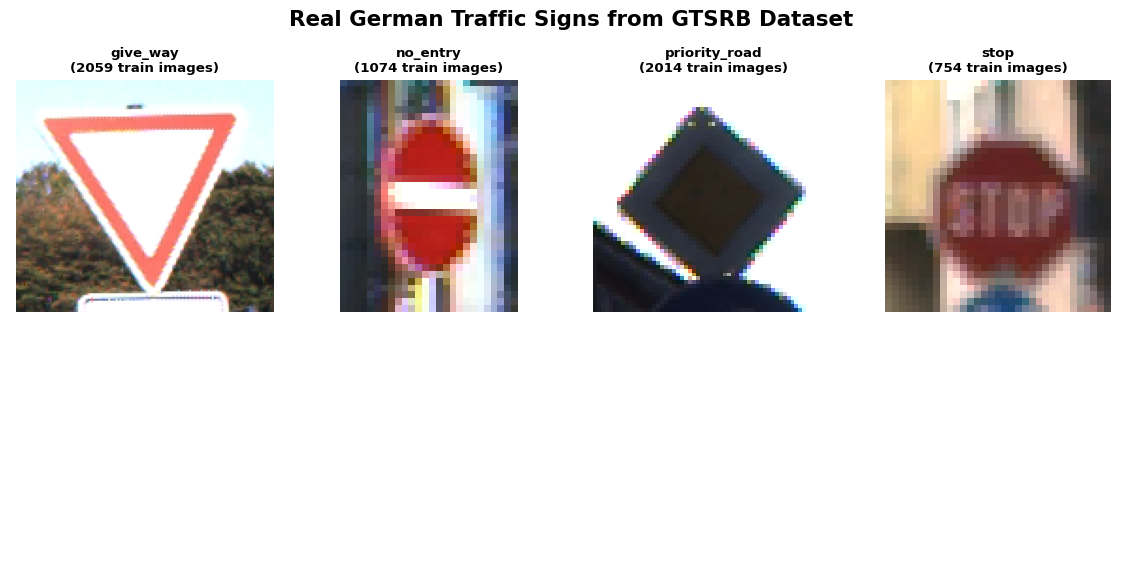


📸 These are real photographs, not synthetic images!
   Notice the variations in lighting, angle, and quality.

In [12]:
from PIL import Image
import random

# Function to display images
def show_image(img_path):
    """Load and display an image."""
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    return img

# Show samples from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    # Get a random image from this class
    class_dir = DATA_DIR / 'train' / class_name
    img_files = list(class_dir.glob('*.ppm'))
    if img_files:
        img_path = random.choice(img_files)
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f'{class_name}\n({len(img_files)} train images)', 
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')

# Hide extra subplots
for idx in range(len(class_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Real German Traffic Signs from GTSRB Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📸 These are real photographs, not synthetic images!")
print("   Notice the variations in lighting, angle, and quality.")

## Data Preprocessing and Augmentation

### Why We Need Preprocessing

Real-world images have challenges:

- **Different sizes**: Traffic sign photos vary in resolution
- **Lighting changes**: Day, night, shadows, glare
- **Angles**: Signs viewed from different perspectives
- **Occlusions**: Signs partially hidden by objects

**Data augmentation** artificially increases training data by applying
random transformations:

------------------------------------------------------------------------

## Why Data Augmentation? The Data Scarcity Problem

Imagine you’re training a model to recognize German traffic signs. You
have 5,000 images: signs at different angles, lighting, weather,
distances.

But here’s the problem: **Real-world signs have infinite variation.** -
A sign at 0° angle, you’ve seen - A sign at 1° angle, probably not in
your dataset - A sign at 15° angle, definitely not - A sign in rain,
snow, fog? Probably not

Your model will **fail catastrophically** on angles and conditions it
hasn’t seen during training. This is called **overfitting to your
specific dataset**.

**What data scientists used to do (2000-2010):** Collect MORE data.
Spend months photographing signs in every condition. Expensive, slow,
impractical.

**Modern approach (2010+): Data Augmentation**

Artificially create new variations from your existing data: - Rotate
images by random amounts (0° to 30°) - Flip left-right (cars can come
from either direction) - Change brightness (sunny, cloudy, night) - Add
noise (rain, fog) - Zoom in/out (signs at different distances)

**The magic:** Your model sees the same sign 1000 different ways. It
learns **“this is a stop sign”** regardless of rotation, lighting, or
angle—not just **“this is the stop sign photo from August 3rd.”**

**Real impact:** Training data of 5,000 images with augmentation =
**functional equivalent to 50,000 images** without it.

This is why modern deep learning works without massive datasets.
Augmentation is how we fake having more data than we actually do.

------------------------------------------------------------------------

### Setting Up Transforms

In [13]:
# ImageNet normalization values (standard for pre-trained models)
# These are the mean and std of ImageNet dataset
mean_nums = [0.485, 0.456, 0.406]
std_nums = [0.229, 0.224, 0.225]

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize all images to 64x64
    transforms.RandomRotation(15),  # Random rotation up to 15 degrees
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary lighting
    transforms.ToTensor(),  # Convert PIL Image to PyTorch tensor
    transforms.Normalize(mean_nums, std_nums)  # Normalize with ImageNet stats
])

# Validation and test transforms (no augmentation, just preprocessing)
val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean_nums, std_nums)
])

# Apply transforms to datasets
# Note: ImageFolder applies transforms on-the-fly when loading images
train_dataset = ImageFolder(DATA_DIR / 'train', transform=train_transform)
val_dataset = ImageFolder(DATA_DIR / 'val', transform=val_test_transform)
test_dataset = ImageFolder(DATA_DIR / 'test', transform=val_test_transform)

print(f"✅ Datasets loaded with transforms:")
print(f"   Training:   {len(train_dataset)} images (with augmentation)")
print(f"   Validation: {len(val_dataset)} images (no augmentation)")
print(f"   Test:       {len(test_dataset)} images (no augmentation)")
print(f"\nClasses: {class_names}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

✅ Datasets loaded with transforms:
   Training:   5901 images (with augmentation)
   Validation: 1173 images (no augmentation)
   Test:       1170 images (no augmentation)

Classes: ['give_way', 'no_entry', 'priority_road', 'stop']
Validation samples: 1173
Test samples: 1170

### Data Loaders

**What is a DataLoader?**

Think of a DataLoader as a **smart delivery system** for your training
data:

- **Batches**: Instead of training on 1 image at a time, we process 32
  images together (more efficient!)
- **Shuffling**: Randomly reorders training data each epoch (prevents
  learning order patterns)
- **Automatic collation**: ImageFolder handles combining samples
  automatically

**Why batch_size = 32?**

- Too small (e.g., 1): Slow training, noisy gradients
- Too large (e.g., 256): Might run out of GPU memory
- 32 is a good balance for most GPUs

In [14]:
# Create data loaders
batch_size = 32  # Number of images processed together

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,           # Shuffle training data each epoch
    num_workers=2           # Use 2 CPU cores to load data in parallel
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,          # Don't shuffle validation (order doesn't matter)
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# Test the loader - get one batch to see the shapes
images, labels = next(iter(train_loader))

print(f"✅ DataLoaders created successfully!")
print(f"\nBatch information:")
print(f"   Images shape: {images.shape}")  # [32, 3, 64, 64]
print(f"   Labels shape: {labels.shape}")   # [32]
print(f"\nBreakdown:")
print(f"   - Batch size: {images.shape[0]} images")
print(f"   - Color channels: {images.shape[1]} (RGB)")
print(f"   - Image size: {images.shape[2]}x{images.shape[3]} pixels")
print(f"\nFirst 5 labels in batch: {labels[:5].tolist()}")
print(f"   Classes: {[class_names[i] for i in labels[:5].tolist()]}")

✅ DataLoaders created successfully!

Batch information:
   Images shape: torch.Size([32, 3, 64, 64])
   Labels shape: torch.Size([32])

Breakdown:
   - Batch size: 32 images
   - Color channels: 3 (RGB)
   - Image size: 64x64 pixels

First 5 labels in batch: [0, 0, 2, 1, 0]
   Classes: ['give_way', 'give_way', 'priority_road', 'no_entry', 'give_way']

## Building a CNN for Traffic Signs

### Understanding the Building Blocks

**Conv2d Layer:**

- Extracts spatial features using kernels
- Parameters: `in_channels`, `out_channels`, `kernel_size`
- Output: Feature maps (learned representations)

**ReLU Activation:**

- Adds non-linearity
- `max(0, x)` - keeps positive values, zeros out negatives

## Why Pooling Layers? The Translation Problem

Here’s a puzzle: You’re training a model to recognize cats in images.

Your training set has cat photos. In photo A, the cat’s face is on the
**left side** of the image. In photo B, the cat’s face is on the **right
side**. Same cat, different position.

**Without Pooling:** A fully connected network that learned “detect eyes
at position (50, 80)” fails when the cat’s eyes move to position (100,
100). To the network, they’re completely different patterns.

More technically: every single pixel position matters. A feature
detected at pixel (50, 80) and a feature at pixel (51, 80) are treated
as unrelated, even though they’re 1 pixel apart.

**Pooling Solution:** Pooling layers downsize the image by taking the
**maximum (or average) value** in small windows: - 4x4 window → 1 output
value - Loses position information (which of the 4 pixels was max?) -
Keeps feature information (was there an edge? Yes/no)

**Why this helps:** - Cat’s face moves 5 pixels left → after pooling,
still looks the same - Network learns “there’s an edge somewhere in this
region” instead of “there’s an edge at pixel 50, 80” - Small
translations don’t matter anymore

**Real-world impact:** A model trained on cats on the left can now
recognize cats on the right, even if it never saw them there before.
This is **translation invariance**.

**Bonus:** Pooling reduces the number of pixels the network has to
process (64x64 → 32x32 → 16x16), making training faster.

------------------------------------------------------------------------

**MaxPool2d:**

- Reduces spatial dimensions by taking max values
- Helps with translation invariance
- Reduces computation

**BatchNorm2d:**

- Normalizes activations to stabilize training
- Allows higher learning rates
- Acts as regularization

## Why Dropout? The Memorization Problem

Imagine you’re memorizing for an exam. You have 10 friends, and whenever
you study, all 10 are in the room. During the exam, you’re alone.

**Problem:** You learned by relying on their presence. You memorized
answers triggered by hearing their voices, not by truly understanding
the material. Alone on the exam, you can’t recall anything.

**Parallel in neural networks:** A network with millions of parameters
can **memorize** the training data without learning general patterns. It
learns specific combinations: “When neuron 47 AND neuron 312 AND neuron
905 are active, this is a stop sign.” But on a new image, this exact
combination never fires.

**Real impact:** High training accuracy (95%), but terrible test
accuracy (60%). The model memorized, not learned.

**The Dropout Solution:**

During training, **randomly disable 50% of neurons**: - Forward pass:
Some neurons are missing - The network can’t rely on any single neuron
or pair of neurons - It’s forced to learn **redundant
representations** - Different subsets of neurons learn to solve the
problem

**What does this mean?** - Neuron 47 alone can’t solve the problem (50%
chance it’s disabled) - But neuron 47 + neuron 80 + neuron 200 working
together can - The network learns more robust features, not brittle
memorization

**During testing:** - All neurons are present (no dropout) - The
ensemble of learned patterns activates together - Generalization
improves dramatically

**Real numbers:** Without dropout, a model might overfit (train 95%,
test 60%). With dropout, it generalizes better (train 88%, test 85%).

------------------------------------------------------------------------

**Dropout:**

- Randomly zeros out neurons during training
- Prevents overfitting
- Forces network to learn robust features

In [15]:
class TrafficSignCNN(nn.Module):
    """
    CNN for German traffic sign classification.
    
    Architecture:
    - Input: 64x64x3 RGB images
    - Conv layers extract features (edges -> textures -> shapes)
    - Fully connected layers for classification
    """
    def __init__(self, num_classes=4):
        super(TrafficSignCNN, self).__init__()
        
        # Convolutional layers
        self.features = nn.Sequential(
            # Layer 1: 64x64 -> 32x32 (after pool)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Layer 2: 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            
            # Layer 3: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
        )
        
        # Calculate size after conv layers: 128 channels * 8x8 = 8192
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

# Create model
model = TrafficSignCNN(num_classes=4).to(device)
print("TrafficSignCNN Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

TrafficSignCNN Architecture:
TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dr

## Training the CNN: The Five Sacred Steps (Now with Images!)

Remember the five steps from Notebook 1? We use the **same process** for
CNNs, just with image data instead of numbers.

### Understanding the Training Loop

**One epoch** = one complete pass through all training data

For our dataset:

- Training samples: ~1,600 images
- Batch size: 32 images
- **Batches per epoch**: 1,600 ÷ 32 = **50 batches**

Each batch goes through these steps:

### Training and Evaluation Functions

In [16]:
def train_epoch(model, loader, optimizer, criterion, device):
    """
    Train the model for one complete epoch.
    
    This function implements the 5 sacred steps of training:
    1. Forward pass (make predictions)
    2. Calculate loss (how wrong were we?)
    3. Zero gradients (clear old gradients)
    4. Backward pass (compute new gradients)
    5. Update weights (adjust parameters)
    """
    model.train()  # Set model to training mode (enables dropout, batch norm)
    running_loss = 0.0  # Track total loss for this epoch
    correct = 0         # Track correct predictions
    total = 0           # Track total samples
    
    # Loop through all batches in the dataset
    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to GPU/CPU
        images, labels = images.to(device), labels.to(device)
        
        # STEP 1: Forward pass
        # Model processes images through all layers
        # Input: [32, 3, 64, 64] -> Output: [32, 4] (4 classes)
        outputs = model(images)
        
        # STEP 2: Calculate loss
        # Compare predictions with true labels
        # CrossEntropyLoss = -log(probability of correct class)
        loss = criterion(outputs, labels)
        
        # STEP 3: Zero gradients
        # Clear gradients from previous batch (PyTorch accumulates by default)
        optimizer.zero_grad()
        
        # STEP 4: Backward pass (backpropagation)
        # Calculate gradients using chain rule
        loss.backward()
        
        # STEP 5: Update weights
        # Adjust parameters to reduce loss (Adam optimizer)
        optimizer.step()
        
        # Track statistics for reporting
        running_loss += loss.item()
        _, predicted = outputs.max(1)  # Get class with highest probability
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)}, Loss: {loss.item():.4f}")
    
    # Calculate epoch statistics
    epoch_loss = running_loss / len(loader)  # Average loss per batch
    epoch_acc = 100. * correct / total        # Accuracy percentage
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    """
    Evaluate model on validation/test set.
    
    Similar to training, but:
    - No gradient computation (faster, saves memory)
    - No weight updates (just measuring performance)
    """
    model.eval()  # Set model to evaluation mode (disables dropout)
    running_loss = 0.0
    correct = 0
    total = 0
    
    # torch.no_grad() disables gradient tracking (faster evaluation)
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass only (no backprop needed)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

### Training Loop

**Before training, we need to set up three key components:**

#### 1. Loss Function (`criterion`)

**What it does:** Measures how wrong our predictions are

- **CrossEntropyLoss**: Used for multi-class classification

  - Combines `LogSoftmax` + `NLLLoss` (Negative Log Likelihood)
  - Penalizes wrong predictions heavily
  - Works with raw logits (no need for softmax in model)

**Example**: If model predicts \[0.7, 0.2, 0.1\] and true label is class
0: - Loss = -log(0.7) ≈ 0.36 (good prediction, low loss)

If model predicts \[0.1, 0.2, 0.7\] and true label is class 0: - Loss =
-log(0.1) ≈ 2.30 (bad prediction, high loss)

#### 2. Optimizer (`optimizer`)

**What it does:** Updates weights to minimize loss

- **Adam**: Adaptive Moment Estimation

  - Combines benefits of RMSprop + momentum
  - Adapts learning rate for each parameter automatically
  - Works well for most deep learning tasks
  - `lr=0.001`: Learning rate (how big are the weight updates?)

**Analogy**: Loss function = compass (tells direction) Optimizer = your
legs (moves you in that direction)

#### 3. Learning Rate Scheduler (`scheduler`)

**What it does:** Reduces learning rate during training

- **StepLR**: Decay learning rate by `gamma` every `step_size` epochs
- `step_size=10`: Reduce LR every 10 epochs
- `gamma=0.1`: Multiply LR by 0.1 (reduce to 10%)

**Why?**: Start with big steps (explore), end with small steps
(fine-tune)

In [17]:
# Setup 1: Loss function
# CrossEntropyLoss expects raw logits, applies softmax internally
criterion = nn.CrossEntropyLoss()

# Setup 2: Optimizer
# Adam will update model.parameters() (all trainable weights)
# lr=0.001 means "make small, careful adjustments"
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Setup 3: Learning rate scheduler
# After 10 epochs, reduce LR from 0.001 to 0.0001
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Track metrics over time for visualization
history = {
    'train_loss': [],    # How wrong on training data
    'train_acc': [],     # Accuracy on training data
    'val_loss': [],      # How wrong on validation data
    'val_acc': []        # Accuracy on validation data
}

# Start training!
print("Training TrafficSignCNN...")
print("=" * 60)
print(f"Training on {len(train_dataset)} images")
print(f"Validating on {len(val_dataset)} images")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")
print("=" * 60)

num_epochs = 20  # How many times to go through all training data
for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")
    
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Evaluate on validation set (no training, just checking performance)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Update learning rate (scheduler step)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"  📊 Training:   Loss={train_loss:.4f} | Acc={train_acc:.2f}%")
    print(f"  📊 Validation: Loss={val_loss:.4f} | Acc={val_acc:.2f}%")
    print(f"  📉 Learning Rate: {current_lr:.6f}")
    
    # Check for overfitting (training much better than validation)
    if train_acc - val_acc > 10:
        print("  ⚠️  Warning: Possible overfitting!")

print("\n✅ Training complete!")
print(f"Final validation accuracy: {history['val_acc'][-1]:.2f}%")

Training TrafficSignCNN...
Training on 5901 images
Validating on 1173 images
Batch size: 32
Batches per epoch: 185

🚀 Epoch 1/20
  Batch 10/185, Loss: 1.7198
  Batch 20/185, Loss: 0.8418
  Batch 30/185, Loss: 0.3365
  Batch 40/185, Loss: 0.4190
  Batch 50/185, Loss: 0.2775
  Batch 60/185, Loss: 0.1387
  Batch 70/185, Loss: 0.3548
  Batch 80/185, Loss: 0.1958
  Batch 90/185, Loss: 0.1389
  Batch 100/185, Loss: 0.1841
  Batch 110/185, Loss: 0.0839
  Batch 120/185, Loss: 0.1127
  Batch 130/185, Loss: 0.0727
  Batch 140/185, Loss: 0.1105
  Batch 150/185, Loss: 0.0273
  Batch 160/185, Loss: 0.0059
  Batch 170/185, Loss: 0.0215
  Batch 180/185, Loss: 0.1792
  📊 Training:   Loss=0.3896 | Acc=86.88%
  📊 Validation: Loss=0.0870 | Acc=97.44%
  📉 Learning Rate: 0.001000

🚀 Epoch 2/20
  Batch 10/185, Loss: 0.0469
  Batch 20/185, Loss: 0.0148
  Batch 30/185, Loss: 0.0252
  Batch 40/185, Loss: 0.0624
  Batch 50/185, Loss: 0.0125
  Batch 60/185, Loss: 0.0348
  Batch 70/185, Loss: 0.0131
  Batch 80/18

### Visualize Training Progress

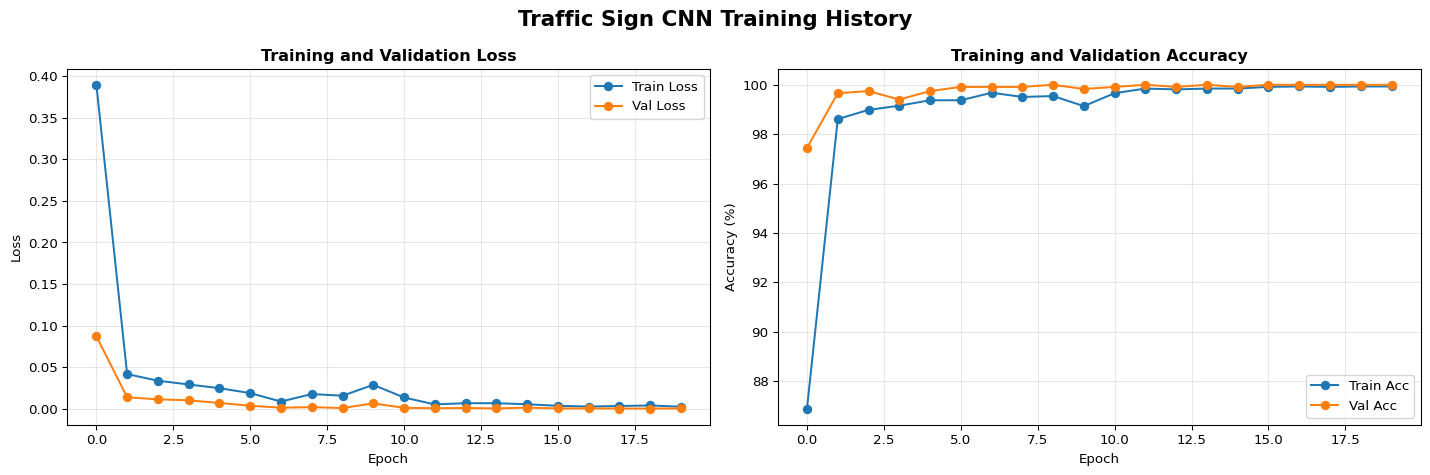

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Traffic Sign CNN Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluation and Testing: Understanding Model Performance

### Why We Need Three Datasets

Remember we split data into **train/validation/test**? Here’s why:

1.  **Training Set** (80%): Used to actually train the model (update
    weights)
2.  **Validation Set** (10%): Used to tune hyperparameters and check for
    overfitting during training
3.  **Test Set** (10%): Used ONLY at the end to get final performance
    metrics

**Important**: The model **never sees the test set** during training or
validation. This gives us an unbiased estimate of real-world
performance.

### Understanding the Metrics

**Loss**: How wrong is the model?

- Lower = better
- Measures confidence and correctness
- Training loss should decrease over time

**Accuracy**: What percentage does the model get right?

- Higher = better
- “Out of 100 images, how many did we classify correctly?”
- 95% accuracy = 95 correct out of 100

**But accuracy can be misleading!** If you have imbalanced classes
(e.g., 90% stop signs, 10% yield), a model could get 90% accuracy just
by always guessing “stop.” That’s why we also look at the confusion
matrix.

### Test Set Performance

In [19]:
# Evaluate on completely unseen test data
print("📊 Final Model Evaluation on Test Set")
print("=" * 50)
print(f"Test dataset size: {len(test_dataset)} images")
print()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"🎯 Test Loss: {test_loss:.4f}")
print(f"   Lower is better. Measures how 'wrong' the predictions are.")
print()
print(f"🎯 Test Accuracy: {test_acc:.2f}%")
print(f"   Out of {len(test_dataset)} test images, model got")
print(f"   {int(test_acc/100 * len(test_dataset))} correct")
print()

# Compare with training accuracy
print(f"📈 Comparison:")
print(f"   Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"   Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"   Test Accuracy: {test_acc:.2f}%")
print()

# Check for overfitting
if history['train_acc'][-1] - test_acc > 10:
    print("⚠️  Warning: Model may be overfitting!")
    print("   Training accuracy much higher than test accuracy.")
    print("   The model memorized training data but doesn't generalize well.")
else:
    print("✅ Model generalizes well! Test accuracy similar to training.")

📊 Final Model Evaluation on Test Set
Test dataset size: 1170 images

🎯 Test Loss: 0.0000
   Lower is better. Measures how 'wrong' the predictions are.

🎯 Test Accuracy: 100.00%
   Out of 1170 test images, model got
   1170 correct

📈 Comparison:
   Training Accuracy: 99.93%
   Validation Accuracy: 100.00%
   Test Accuracy: 100.00%

✅ Model generalizes well! Test accuracy similar to training.

### Confusion Matrix: Understanding Mistakes

**What is a Confusion Matrix?**

A table that shows:

- **Rows**: Actual class (what the image really is)
- **Columns**: Predicted class (what the model thought it was)
- **Diagonal**: Correct predictions ✓
- **Off-diagonal**: Mistakes ✗

**Example**: If the model confuses “Stop” signs with “No Entry” signs,
you’ll see a high number in the Stop row, No Entry column.

**Why it matters**: Accuracy only tells you “95% correct.” Confusion
matrix tells you WHICH 5% were wrong and what they were confused with.

📊 Analyzing model predictions...
Total test samples: 1170
Total predictions: 1170

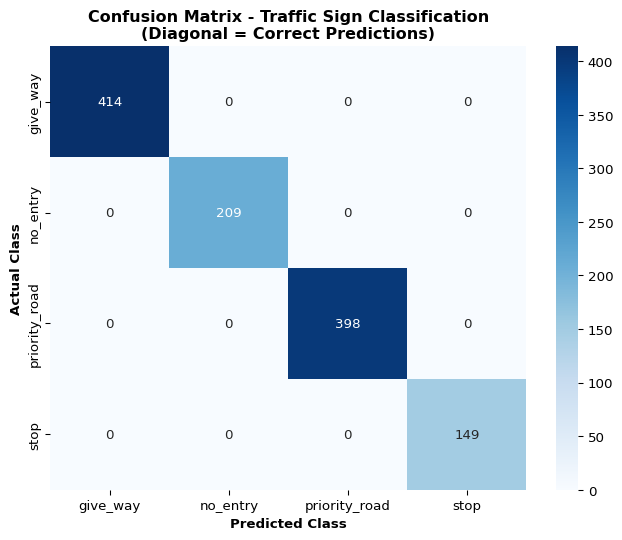


📊 Per-Class Performance:
--------------------------------------------------
give_way       : 100.0% (414/414)
no_entry       : 100.0% (209/209)
priority_road  : 100.0% (398/398)
stop           : 100.0% (149/149)

📊 Detailed Classification Report:

What these metrics mean:
  Precision: Of all predicted X, how many were actually X?
  Recall:    Of all actual X, how many did we find?
  F1-Score:  Harmonic mean of precision and recall

               precision    recall  f1-score   support

     give_way       1.00      1.00      1.00       414
     no_entry       1.00      1.00      1.00       209
priority_road       1.00      1.00      1.00       398
         stop       1.00      1.00      1.00       149

     accuracy                           1.00      1170
    macro avg       1.00      1.00      1.00      1170
 weighted avg       1.00      1.00      1.00      1170


In [20]:
def get_predictions(model, loader, device):
    """
    Get all predictions and true labels from a dataset.
    
    This function:
    1. Sets model to evaluation mode (no dropout, batch norm uses running stats)
    2. Processes all images in the loader
    3. Collects predictions and true labels
    4. Returns them as numpy arrays for analysis
    """
    model.eval()  # Evaluation mode - no training behavior
    all_preds = []
    all_labels = []
    
    # No gradient computation needed (faster, saves memory)
    with torch.no_grad():
        for images, labels in loader:
            # Move to device
            images = images.to(device)
            
            # Get model predictions
            outputs = model(images)
            _, predicted = outputs.max(1)  # Get class with highest score
            
            # Move back to CPU and convert to numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions for the entire test set
print("📊 Analyzing model predictions...")
y_pred, y_true = get_predictions(model, test_loader, device)

print(f"Total test samples: {len(y_true)}")
print(f"Total predictions: {len(y_pred)}")

# Create confusion matrix
# Rows = True labels, Columns = Predicted labels
cm = confusion_matrix(y_true, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Class', fontweight='bold')
plt.ylabel('Actual Class', fontweight='bold')
plt.title('Confusion Matrix - Traffic Sign Classification\n(Diagonal = Correct Predictions)', 
          fontweight='bold')
plt.show()

# Calculate per-class accuracy
print("\n📊 Per-Class Performance:")
print("-" * 50)
for i, class_name in enumerate(class_names):
    true_positives = cm[i, i]  # Correct predictions for this class
    total_actual = cm[i, :].sum()  # Total actual instances of this class
    class_accuracy = 100 * true_positives / total_actual
    print(f"{class_name:15s}: {class_accuracy:.1f}% ({true_positives}/{total_actual})")

# Classification report with detailed metrics
print("\n📊 Detailed Classification Report:")
print("=" * 60)
print("\nWhat these metrics mean:")
print("  Precision: Of all predicted X, how many were actually X?")
print("  Recall:    Of all actual X, how many did we find?")
print("  F1-Score:  Harmonic mean of precision and recall")
print()
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

### Visualize Predictions

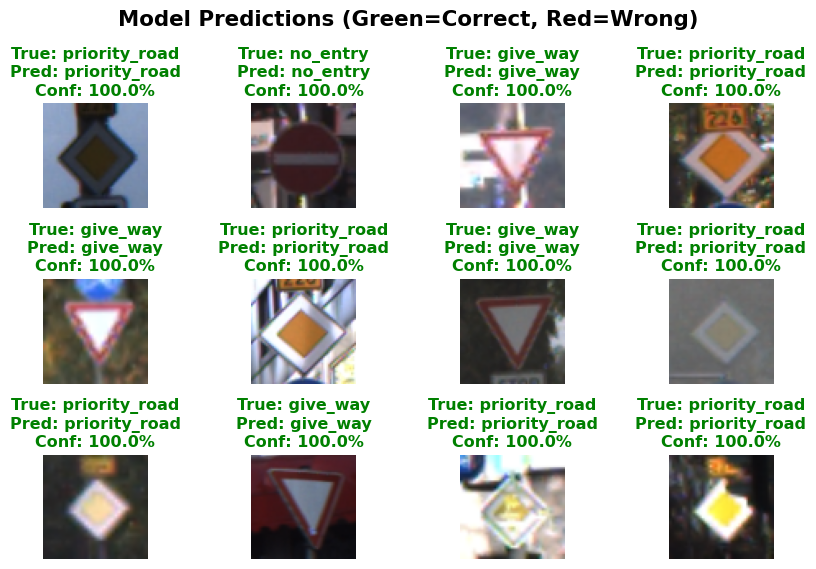

In [21]:
def visualize_predictions(model, dataset, class_names, n_samples=12):
    """Visualize model predictions."""
    model.eval()
    
    # Get random samples
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(9, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]
        
        # Make prediction
        with torch.no_grad():
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            probs = F.softmax(output, dim=1)[0]
            pred_label = probs.argmax().item()
        
        # Plot
        # Denormalize for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = image * std + mean
        img_display = torch.clamp(img_display, 0, 1)
        
        axes[i].imshow(img_display.permute(1, 2, 0).numpy())
        
        color = 'green' if pred_label == true_label else 'red'
        axes[i].set_title(
            f'True: {class_names[true_label]}\n'
            f'Pred: {class_names[pred_label]}\n'
            f'Conf: {probs[pred_label]:.1%}',
            color=color, fontweight='bold'
        )
        axes[i].axis('off')
    
    plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize predictions
visualize_predictions(model, test_dataset, class_names, n_samples=12)

------------------------------------------------------------------------

# The Power of Transfer Learning (Preview)

Training CNNs from scratch requires lots of data and time. In the next
notebook, we’ll learn **Transfer Learning** - using pre-trained models
like ResNet that were trained on millions of images.

**Benefits:**

- Train with 1,000 images instead of 100,000
- Get better accuracy in minutes instead of days
- Works even with small datasets

**Quick example:**

In [22]:
from torchvision import models

# Load pre-trained ResNet18 (trained on ImageNet)
resnet = models.resnet18(pretrained=True)

# Freeze base layers (keep learned features)
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer for our 4 classes
resnet.fc = nn.Linear(resnet.fc.in_features, 4)

# Now train only the final layer - much faster!

------------------------------------------------------------------------

# Summary & Key Takeaways

## CNN Building Blocks

| Component | Purpose | PyTorch Class |
|-----------------------|-------------------|-------------------------------|
| **Conv2d** | Extract spatial features | `nn.Conv2d` |
| **ReLU** | Add non-linearity | `nn.ReLU` |
| **MaxPool** | Reduce spatial size, add translation invariance | `nn.MaxPool2d` |
| **BatchNorm** | Stabilize training | `nn.BatchNorm2d` |
| **Dropout** | Prevent overfitting | `nn.Dropout` |
| **Linear** | Final classification | `nn.Linear` |

## Key Concepts

**Weight Sharing**: Same kernel used across entire image → fewer
parameters

**Feature Hierarchy**:

- Layer 1: Detects edges and colors
- Layer 2: Detects textures and patterns  
- Layer 3: Detects object parts
- Layer 4+: Detects complete objects

**Data Augmentation**: Artificially increase training data with
transformations

## Common CNN Architectures

| Architecture  | Year | Key Innovation              | Parameters |
|---------------|------|-----------------------------|------------|
| **LeNet**     | 1998 | First successful CNN        | 60K        |
| **AlexNet**   | 2012 | ReLU, Dropout, GPU training | 60M        |
| **VGG**       | 2014 | Deep 3x3 convolutions       | 138M       |
| **ResNet**    | 2015 | Skip connections            | 25M        |
| **MobileNet** | 2017 | Efficient for mobile        | 4M         |

## Why CNNs Beat Fully Connected Networks

| Aspect                     | Fully Connected | CNN                   |
|----------------------------|-----------------|-----------------------|
| **Parameters**             | Millions        | Thousands to millions |
| **Spatial awareness**      | None            | Built-in              |
| **Translation invariance** | No              | Yes                   |
| **Training data needed**   | Huge            | Moderate              |
| **Overfitting risk**       | High            | Lower                 |

------------------------------------------------------------------------

# Practice Exercises

## Exercise 1: Modify the Architecture

Experiment with different CNN architectures:

In [23]:
class CustomTrafficSignCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomTrafficSignCNN, self).__init__()
        # Experiment with:
        # - Number of layers
        # - Number of filters per layer
        # - Kernel sizes (3x3 vs 5x5)
        # - With/without BatchNorm
        # - With/without Dropout
        
        self.features = nn.Sequential(
            # Your layers here
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Add more layers...
        )
        
        self.classifier = nn.Sequential(
            # Your classifier here
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Questions:
# What happens if you remove BatchNorm? (Training becomes unstable)
# What happens with higher dropout (0.7)? (May underfit)
# Does kernel size matter? (Larger kernels = larger receptive field)
# Is deeper always better? (Not if you overfit!)

## Exercise 2: Visualize Learned Features

In [24]:
# Get first convolutional layer weights
first_conv = model.features[0]  # First Conv2d layer
filters = first_conv.weight.data.cpu()

print(f"Filter shape: {filters.shape}")  # [out_channels, in_channels, H, W]

# Visualize filters
fig, axes = plt.subplots(4, 8, figsize=(9, 6))
axes = axes.flatten()

for i in range(min(32, len(axes))):
    # Get filter for first input channel
    filter_img = filters[i, 0, :, :].numpy()
    axes[i].imshow(filter_img, cmap='RdBu_r')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('First Layer Learned Filters', fontsize=16)
plt.tight_layout()
plt.show()

# What patterns do the filters detect?
# Some will look like edge detectors, others like color detectors

## Exercise 3: Test Model Confidence

One challenge in production: How confident is the model in its
predictions?

In [25]:
# Get prediction probabilities for test images
model.eval()
with torch.no_grad():
    # Get a batch from test set
    images, labels = next(iter(test_loader))
    images = images.to(device)
    
    # Get raw outputs and probabilities
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)
    
    # Find predictions with low confidence (< 70%)
    max_probs, predictions = probs.max(1)
    low_confidence_mask = max_probs < 0.7
    
    print(f"Low confidence predictions: {low_confidence_mask.sum().item()}/{len(images)}")
    
    # Display uncertain predictions
    uncertain_indices = low_confidence_mask.nonzero(as_tuple=True)[0]
    for idx in uncertain_indices[:5]:  # Show first 5
        print(f"Image {idx.item()}: {max_probs[idx].item():.1%} confident")
        print(f"  Predicted: {class_names[predictions[idx]]}")
        print(f"  Actual: {class_names[labels[idx]]}")
        print()

# Analysis questions:
# - When is the model uncertain?
# - Does uncertainty correlate with errors?
# - How can we handle uncertain predictions in production?

## Exercise 4: Compare with Fully Connected

In [26]:
class FullyConnectedTrafficSign(nn.Module):
    """Fully connected network for comparison."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64*64*3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        return x

# Compare:
# Number of parameters
# Training time per epoch
# Final accuracy
# Training stability

fc_model = FullyConnectedTrafficSign().to(device)
fc_params = sum(p.numel() for p in fc_model.parameters())
cnn_params = sum(p.numel() for p in model.parameters())

print(f"Fully Connected params: {fc_params:,}")
print(f"CNN params: {cnn_params:,}")
print(f"Ratio: {fc_params / cnn_params:.1f}x more parameters!")

------------------------------------------------------------------------

**Congratulations!** You’ve built your first Convolutional Neural
Network and applied it to a real computer vision task - traffic sign
recognition.

**What you learned:**

- How convolutions work (sliding kernels, weight sharing)
- CNN architecture (Conv → ReLU → Pool → Repeat)
- Data augmentation for computer vision
- Training CNNs with PyTorch
- Evaluating and visualizing predictions

**Next Steps:** In Notebook 3, we’ll learn **Transfer Learning** - using
pre-trained models like ResNet to get state-of-the-art results with
minimal training data and time.

*“The best way to learn computer vision is to see the features the
network learns. Start with edges, progress to textures, and end with
objects.”*